# NexusTrader Experiments — Persistent Scoring & Analysis Notebook

This notebook is redesigned for **reusable, persistent evaluation**.

What it guarantees each run:
1. Load raw JSONL agent outputs
2. Score every row consistently
3. Upsert scored rows into long-lived registries
4. Save timestamped analysis bundles (CSV + JSON + charts)
5. Keep comparisons reproducible across run tags

Use this as the single source of truth for experiment reporting.

In [1]:
from __future__ import annotations

import json
import random
from datetime import datetime, timedelta
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
pd.set_option("display.max_columns", 200)

## 1) Global Configuration

In [2]:
ROOT = Path(r"c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments")
RAW_DIR = ROOT / "results" / "raw"
SCORED_DIR = ROOT / "results" / "scored"
CHART_DIR = ROOT / "results" / "charts"
REPORT_DIR = ROOT / "results" / "analysis_reports"

SCORED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MAP = {"short": 10, "medium": 21, "long": 126}
HOLD_EPSILON = 0.025
RANDOM_SEED = 42

AGENT_RUN_GLOB = "batch_eval385_stageD_llm_lessons_v1_20260321_175911.jsonl"

# Baseline controls
ENABLE_BASELINES = True

print("RAW_DIR:", RAW_DIR)
print("Matched agent JSONL files:", len(list(RAW_DIR.glob(AGENT_RUN_GLOB))))

RAW_DIR: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\raw
Matched agent JSONL files: 1


## 2) Core Helpers (Price Fetch, Scoring, Parsing)

In [3]:
import re
import yfinance as yf

@lru_cache(maxsize=4096)
def get_close_series(ticker: str, start_iso: str, end_iso: str):
    hist = yf.Ticker(ticker).history(start=start_iso, end=end_iso, auto_adjust=True)
    if hist.empty:
        return None
    s = hist["Close"].dropna()
    return s

def k_return(ticker: str, as_of: str, k: int):
    t0 = datetime.fromisoformat(as_of)
    t1 = t0 + timedelta(days=max(14, 4 * k))
    s = get_close_series(ticker, t0.date().isoformat(), t1.date().isoformat())
    if s is None or len(s) <= k:
        return np.nan
    p0 = float(s.iloc[0])
    pk = float(s.iloc[k])
    if p0 == 0:
        return np.nan
    return (pk - p0) / p0

def directional_correct(action: str, ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    a = (action or "HOLD").upper()
    if a == "BUY":
        return 1 if ret > 0 else 0
    if a == "SELL":
        return 1 if ret < 0 else 0
    if a == "HOLD":
        return 1 if abs(ret) < hold_epsilon else 0
    return np.nan

def true_direction_label(ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    if abs(ret) < hold_epsilon:
        return "HOLD"
    return "BUY" if ret > 0 else "SELL"

def extract_agent_action(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    return (ts.get("action") or "HOLD").upper()

def extract_confidence_band(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    rationale = (ts.get("rationale") or "")
    m = re.search(r"CONFIDENCE\s*[=:]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m2 = re.search(r"confidence\s*band\s*[:=]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m2:
        return m2.group(1).upper()
    return "UNKNOWN"

def parse_tag_and_timestamp(filename: str):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 4:
        return stem, "unknown"
    ts = "_".join(parts[-2:])
    tag = "_".join(parts[1:-2])
    return tag, ts

## 3) Load Agent JSONL and Persist Scored Registry

In [4]:
def load_agent_runs(raw_dir: Path, pattern: str):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        run_tag, run_ts = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue

                ticker = obj.get("ticker")
                simulated_date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, simulated_date, k)

                rows.append({
                    "source": "agent",
                    "strategy": "nexustrader",
                    "run_file": p.name,
                    "run_tag": run_tag,
                    "run_timestamp": run_ts,
                    "ticker": ticker,
                    "simulated_date": simulated_date,
                    "horizon": horizon,
                    "k": int(k),
                    "action": action,
                    "k_return": ret,
                    "correct": directional_correct(action, ret),
                    "true_label": true_direction_label(ret),
                    "confidence_band": extract_confidence_band(obj),
                })

    return pd.DataFrame(rows)

AGENT_REGISTRY_PATH = SCORED_DIR / "agent_runs_scored_registry.csv"
incoming_agent_df = load_agent_runs(RAW_DIR, AGENT_RUN_GLOB)

if AGENT_REGISTRY_PATH.exists():
    agent_registry_df = pd.read_csv(AGENT_REGISTRY_PATH)
else:
    agent_registry_df = pd.DataFrame(columns=incoming_agent_df.columns)

if not incoming_agent_df.empty:
    agent_registry_df = pd.concat([agent_registry_df, incoming_agent_df], ignore_index=True)
    key_cols = ["run_file", "ticker", "simulated_date", "horizon", "k", "action"]
    agent_registry_df = agent_registry_df.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)
    agent_registry_df.to_csv(AGENT_REGISTRY_PATH, index=False)

analysis_agent_df = incoming_agent_df.copy() if not incoming_agent_df.empty else agent_registry_df.copy()

print("Incoming rows:", len(incoming_agent_df))
print("Registry rows:", len(agent_registry_df))
print("Analysis rows:", len(analysis_agent_df))
print("Saved registry:", AGENT_REGISTRY_PATH)
display(analysis_agent_df.head(3))

Incoming rows: 385
Registry rows: 6905
Analysis rows: 385
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\agent_runs_scored_registry.csv


,source,strategy,run_file,run_tag,run_timestamp,ticker,simulated_date,horizon,k,action,k_return,correct,true_label,confidence_band
0,agent,nexustrader,batch_eval385_stageD_llm_lessons_v1_20260321_1...,eval385_stageD_llm_lessons_v1,20260321_175911,AAPL,2021-12-06,short,10,BUY,0.026797,1,BUY,UNKNOWN
1,agent,nexustrader,batch_eval385_stageD_llm_lessons_v1_20260321_1...,eval385_stageD_llm_lessons_v1,20260321_175911,AAPL,2021-09-13,short,10,SELL,-0.027950,1,SELL,UNKNOWN
2,agent,nexustrader,batch_eval385_stageD_llm_lessons_v1_20260321_1...,eval385_stageD_llm_lessons_v1,20260321_175911,AAPL,2021-10-04,short,10,SELL,0.053256,0,BUY,UNKNOWN


## 4) Build Universe and Optional Baselines

In [5]:
if analysis_agent_df.empty:
    raise RuntimeError("No agent rows available. Check AGENT_RUN_GLOB and raw files.")

universe = (
    analysis_agent_df[["ticker", "simulated_date", "horizon", "k"]]
    .drop_duplicates()
    .sort_values(["ticker", "simulated_date", "horizon"])
    .reset_index(drop=True)
)

n_tickers = universe["ticker"].nunique()
n_dates = universe["simulated_date"].nunique()
print(f"Universe rows={len(universe)}, tickers={n_tickers}, dates={n_dates}, tickers*dates={n_tickers*n_dates}")
display(universe.head(10))

Universe rows=385, tickers=5, dates=77, tickers*dates=385


,ticker,simulated_date,horizon,k
0,AAPL,2021-09-13,short,10
1,AAPL,2021-10-04,short,10
2,AAPL,2021-10-25,short,10
3,AAPL,2021-11-15,short,10
4,AAPL,2021-12-06,short,10
5,AAPL,2021-12-27,short,10
6,AAPL,2022-01-17,short,10
7,AAPL,2022-02-07,short,10
8,AAPL,2022-02-28,short,10
9,AAPL,2022-03-21,short,10


## 5) Baseline Definitions and Baseline Registry

In [6]:
def baseline_buy_hold(_ticker: str, _date: str):
    return "BUY"

def baseline_sma(ticker: str, date: str, short_w: int = 20, long_w: int = 50):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=3 * long_w)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < long_w:
        return "HOLD"
    sma_s = s.tail(short_w).mean()
    sma_l = s.tail(long_w).mean()
    if sma_s > 1.01 * sma_l:
        return "BUY"
    if sma_s < 0.99 * sma_l:
        return "SELL"
    return "HOLD"

def baseline_rsi(ticker: str, date: str, period: int = 14):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=6 * period)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < period + 1:
        return "HOLD"
    d = s.diff().dropna()
    up = d.clip(lower=0).tail(period).mean()
    dn = (-d.clip(upper=0)).tail(period).mean()
    rs = up / (dn + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    if rsi < 30:
        return "BUY"
    if rsi > 70:
        return "SELL"
    return "HOLD"

_rng = random.Random(RANDOM_SEED)
def baseline_random(_ticker: str, _date: str):
    return _rng.choice(["BUY", "SELL", "HOLD"])

## 6) Compute/Upsert Baselines (Optional)

In [7]:
baseline_specs = {
    "buy_hold": baseline_buy_hold,
    "sma_crossover": baseline_sma,
    "rsi_14": baseline_rsi,
    "random_uniform": baseline_random,
}

BASELINE_REGISTRY_PATH = SCORED_DIR / "baselines_registry.csv"
baseline_df = pd.DataFrame()

if ENABLE_BASELINES:
    if BASELINE_REGISTRY_PATH.exists():
        baseline_registry_df = pd.read_csv(BASELINE_REGISTRY_PATH)
    else:
        baseline_registry_df = pd.DataFrame(columns=[
            "source", "strategy", "run_file", "run_tag", "run_timestamp",
            "ticker", "simulated_date", "horizon", "k", "action", "k_return", "correct", "true_label", "confidence_band"
        ])

    needed = (
        universe.assign(_tmp=1)
        .merge(pd.DataFrame({"strategy": list(baseline_specs.keys()), "_tmp": 1}), on="_tmp")
        .drop(columns="_tmp")[["strategy", "ticker", "simulated_date", "horizon", "k"]]
        .reset_index(drop=True)
    )

    existing_keys = baseline_registry_df[["strategy", "ticker", "simulated_date", "horizon", "k"]].drop_duplicates() if not baseline_registry_df.empty else pd.DataFrame(columns=["strategy", "ticker", "simulated_date", "horizon", "k"])
    missing = needed.merge(existing_keys, on=["strategy", "ticker", "simulated_date", "horizon", "k"], how="left", indicator=True)
    missing = missing[missing["_merge"].eq("left_only")].drop(columns="_merge")

    new_rows = []
    for r in missing.itertuples(index=False):
        fn = baseline_specs[r.strategy]
        action = fn(r.ticker, r.simulated_date)
        ret = k_return(r.ticker, r.simulated_date, int(r.k))
        new_rows.append({
            "source": "baseline",
            "strategy": r.strategy,
            "run_file": "baseline_recomputed",
            "run_tag": "baseline",
            "run_timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
            "ticker": r.ticker,
            "simulated_date": r.simulated_date,
            "horizon": r.horizon,
            "k": int(r.k),
            "action": action,
            "k_return": ret,
            "correct": directional_correct(action, ret),
            "true_label": true_direction_label(ret),
            "confidence_band": "N/A",
        })

    new_baselines_df = pd.DataFrame(new_rows)
    baseline_registry_df = pd.concat([baseline_registry_df, new_baselines_df], ignore_index=True)
    baseline_registry_df = baseline_registry_df.drop_duplicates(subset=["strategy", "ticker", "simulated_date", "horizon", "k"], keep="last").reset_index(drop=True)
    baseline_registry_df.to_csv(BASELINE_REGISTRY_PATH, index=False)

    baseline_df = baseline_registry_df.merge(
        universe[["ticker", "simulated_date", "horizon", "k"]].drop_duplicates(),
        on=["ticker", "simulated_date", "horizon", "k"],
        how="inner"
    ).reset_index(drop=True)

    print("Baseline rows used:", len(baseline_df), "| New rows computed:", len(new_baselines_df))
    print("Saved registry:", BASELINE_REGISTRY_PATH)
else:
    print("Baselines disabled.")

Baseline rows used: 1540 | New rows computed: 0
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\baselines_registry.csv


## 7) Reusable Analysis Functions (Primary + Secondary Metrics)

In [8]:
def directional_accuracy_ex_hold(df: pd.DataFrame):
    d = df[df["action"].isin(["BUY", "SELL"])].copy()
    if d.empty:
        return np.nan, 0
    acc = d["correct"].mean() * 100
    return acc, len(d)

def hold_quality(df: pd.DataFrame, eps: float = HOLD_EPSILON):
    h = df[df["action"].eq("HOLD")].copy()
    if h.empty:
        return {"hold_n": 0, "hold_rate_%": 0.0, "hold_precision_%": np.nan, "hold_far_miss_n": 0}
    h["abs_ret"] = h["k_return"].abs()
    hold_precision = (h["abs_ret"] < eps).mean() * 100
    return {
        "hold_n": int(len(h)),
        "hold_rate_%": len(h) / max(len(df), 1) * 100,
        "hold_precision_%": hold_precision,
        "hold_far_miss_n": int((h["abs_ret"] >= eps).sum()),
    }

def strategy_return_series(df: pd.DataFrame):
    d = df.copy()
    d["strategy_return"] = np.where(
        d["action"].eq("BUY"), d["k_return"],
        np.where(d["action"].eq("SELL"), -d["k_return"], 0.0)
    )
    d["buy_hold_return"] = d["k_return"]
    d["excess_vs_buy_hold"] = d["strategy_return"] - d["buy_hold_return"]
    return d

def summarize_group(df: pd.DataFrame, group_col: str):
    out = []
    for name, g in df.groupby(group_col):
        dacc, dacc_n = directional_accuracy_ex_hold(g)
        hold = hold_quality(g)
        ret_df = strategy_return_series(g.dropna(subset=["k_return"]).copy())

        out.append({
            "name": name,
            "n": int(len(g)),
            "overall_acc_%": round(g["correct"].mean() * 100, 2),
            "dir_acc_ex_hold_%": round(dacc, 2) if not pd.isna(dacc) else np.nan,
            "dir_acc_ex_hold_n": int(dacc_n),
            "buy_acc_%": round(g.loc[g.action.eq("BUY"), "correct"].mean() * 100, 2) if (g.action == "BUY").any() else np.nan,
            "sell_acc_%": round(g.loc[g.action.eq("SELL"), "correct"].mean() * 100, 2) if (g.action == "SELL").any() else np.nan,
            "hold_acc_%": round(g.loc[g.action.eq("HOLD"), "correct"].mean() * 100, 2) if (g.action == "HOLD").any() else np.nan,
            "buy_n": int((g.action == "BUY").sum()),
            "sell_n": int((g.action == "SELL").sum()),
            "hold_n": hold["hold_n"],
            "hold_rate_%": round(hold["hold_rate_%"], 2),
            "hold_precision_%": round(hold["hold_precision_%"], 2) if not pd.isna(hold["hold_precision_%"]) else np.nan,
            "mean_strategy_return_%": round(ret_df["strategy_return"].mean() * 100, 3) if not ret_df.empty else np.nan,
            "mean_excess_vs_bh_%": round(ret_df["excess_vs_buy_hold"].mean() * 100, 3) if not ret_df.empty else np.nan,
        })
    return pd.DataFrame(out).sort_values(["dir_acc_ex_hold_%", "overall_acc_%"], ascending=False).reset_index(drop=True)

def bootstrap_ci_mean(x, n_boot=5000, ci=95, seed=42):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        means[i] = rng.choice(x, size=n, replace=True).mean()
    alpha = (100 - ci) / 2
    lo = float(np.percentile(means, alpha))
    hi = float(np.percentile(means, 100 - alpha))
    return float(x.mean()), lo, hi

## 8) Build Current Analysis and Save Bundle

In [9]:
agent_summary = summarize_group(analysis_agent_df, "run_tag")
baseline_summary = summarize_group(baseline_df, "strategy") if ENABLE_BASELINES and not baseline_df.empty else pd.DataFrame()

display(agent_summary)
if not baseline_summary.empty:
    display(baseline_summary)

analysis_ts = datetime.now().strftime("%Y%m%d_%H%M%S")

run_tags = sorted(str(x) for x in analysis_agent_df["run_tag"].dropna().unique()) if not analysis_agent_df.empty else []
if len(run_tags) == 1:
    bundle_tag = run_tags[0]
elif len(run_tags) > 1:
    shown = run_tags[:3]
    suffix = f"__plus_{len(run_tags) - 3}" if len(run_tags) > 3 else ""
    bundle_tag = "__".join(shown) + suffix
else:
    bundle_tag = AGENT_RUN_GLOB.replace("*", "ALL")

safe_bundle_tag = re.sub(r"[^A-Za-z0-9._-]+", "_", bundle_tag).strip("._-") or "analysis"
bundle_dir = REPORT_DIR / safe_bundle_tag
bundle_dir.mkdir(parents=True, exist_ok=True)

agent_rows_path = bundle_dir / "agent_rows_scored.csv"
agent_summary_path = bundle_dir / "agent_summary.csv"
analysis_agent_df.to_csv(agent_rows_path, index=False)
agent_summary.to_csv(agent_summary_path, index=False)

if not baseline_summary.empty:
    baseline_rows_path = bundle_dir / "baseline_rows_scored.csv"
    baseline_summary_path = bundle_dir / "baseline_summary.csv"
    baseline_df.to_csv(baseline_rows_path, index=False)
    baseline_summary.to_csv(baseline_summary_path, index=False)

meta = {
    "created_at": analysis_ts,
    "bundle_tag": bundle_tag,
    "bundle_dir": str(bundle_dir),
    "agent_glob": AGENT_RUN_GLOB,
    "run_tags": run_tags,
    "agent_rows": int(len(analysis_agent_df)),
    "unique_tickers": int(analysis_agent_df["ticker"].nunique()) if not analysis_agent_df.empty else 0,
    "unique_dates": int(analysis_agent_df["simulated_date"].nunique()) if not analysis_agent_df.empty else 0,
    "hold_epsilon": HOLD_EPSILON,
    "enable_baselines": ENABLE_BASELINES,
}
with (bundle_dir / "meta.json").open("w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved analysis bundle:", bundle_dir)
print("Bundle tag:", bundle_tag)
print("-", agent_rows_path.name)
print("-", agent_summary_path.name)
if ENABLE_BASELINES and not baseline_summary.empty:
    print("- baseline rows/summary")

,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,eval385_stageD_llm_lessons_v1,385,51.17,54.3,302,60.92,45.31,39.76,174,128,83,21.56,39.76,0.354,-1.108


,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,buy_hold,385,59.22,59.22,385,59.22,NaN,NaN,385,0,0,0.00,NaN,1.463,0.000
1,sma_crossover,385,51.43,53.99,313,60.00,43.36,40.28,200,113,72,18.70,48.61,0.417,-1.046
2,random_uniform,385,40.26,44.13,247,52.94,33.33,33.33,136,111,138,35.84,40.58,-0.380,-1.843
3,rsi_14,385,34.29,43.81,105,58.33,36.23,30.71,36,69,280,72.73,38.93,-0.400,-1.863


Saved analysis bundle: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval385_stageD_llm_lessons_v1
Bundle tag: eval385_stageD_llm_lessons_v1
- agent_rows_scored.csv
- agent_summary.csv
- baseline rows/summary


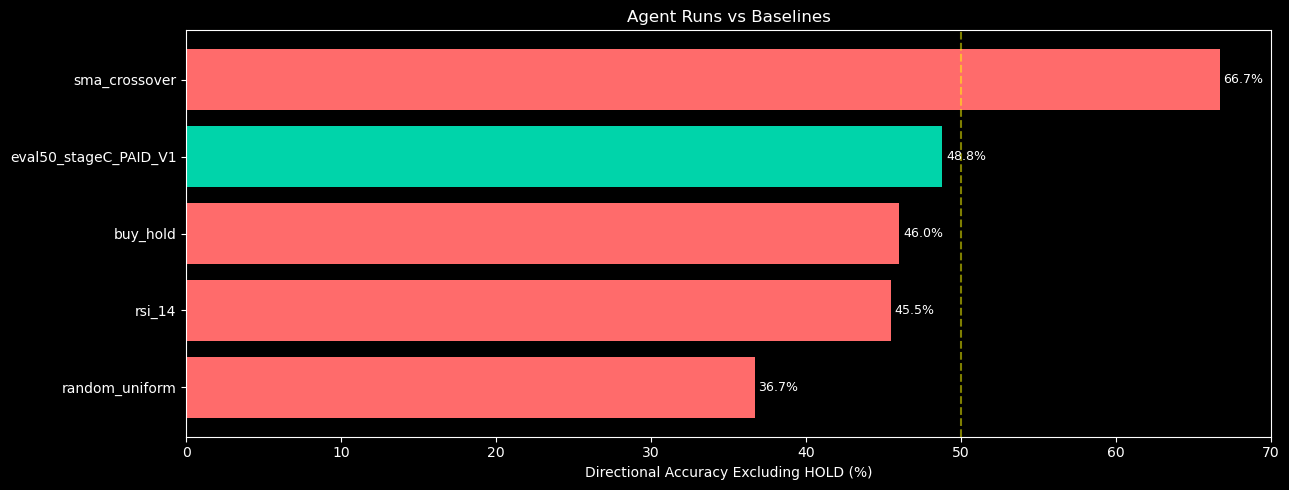

Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval50_stageC_PAID_V1\chart_dir_acc_ex_hold.png


In [10]:
plot_df = pd.DataFrame()
if not agent_summary.empty:
    plot_df = pd.concat([plot_df, agent_summary.assign(group="agent")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)
if not baseline_summary.empty:
    plot_df = pd.concat([plot_df, baseline_summary.assign(group="baseline")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)

plot_df = plot_df.dropna(subset=["dir_acc_ex_hold_%"]).sort_values("dir_acc_ex_hold_%", ascending=True).reset_index(drop=True)

if not plot_df.empty:
    
    fig, ax = plt.subplots(figsize=(13, max(5, 0.55 * len(plot_df))))
    colors = ["#00d4aa" if g == "agent" else "#ff6b6b" for g in plot_df["group"]]
    ax.barh(plot_df["name"], plot_df["dir_acc_ex_hold_%"], color=colors)
    ax.axvline(50, color="yellow", linestyle="--", alpha=0.5)
    ax.set_xlabel("Directional Accuracy Excluding HOLD (%)")
    ax.set_title("Agent Runs vs Baselines")
    for y, v in enumerate(plot_df["dir_acc_ex_hold_%"]):
        ax.text(v + 0.25, y, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    chart_path = bundle_dir / "chart_dir_acc_ex_hold.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("No rows to plot.")

In [11]:
# ── Run 1 vs Run 2 — explicit date-matched fair ablation ───────────────────
"""
Build the fair comparison set from an explicit date list.
This avoids accidental distribution mismatch when one file covers more dates than the other.
"""

RUN_1_FILE = "batch_eval385_stageB_plus_v3_20260318_162135.jsonl"
RUN_1_LABEL = "Stage B+"

RUN_2_FILE = "batch_eval385_stageC_r1_v9_20260319_222256.jsonl"
RUN_2_LABEL = "Stage C"

DATES_FILE = ROOT / "inputs" / "dates_expanded.txt"

def load_date_list(path: Path) -> list[str]:
    dates = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            d = line.strip()
            if d:
                dates.append(d)
    return dates

EVAL_DATES = load_date_list(DATES_FILE)
print(f"Loaded {len(EVAL_DATES)} target dates from {DATES_FILE.name}")

def load_run_filtered(filename: str, label: str, allowed_dates: set[str] | None = None) -> pd.DataFrame:
    rows = []
    p = RAW_DIR / filename
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue

            ticker = obj.get("ticker")
            sim_date = obj.get("simulated_date")
            if allowed_dates is not None and sim_date not in allowed_dates:
                continue

            horizon = obj.get("horizon", "short")
            k = HORIZON_MAP.get(horizon, 10)
            action = extract_agent_action(obj)
            ret = k_return(ticker, sim_date, k)
            ts = ((obj.get("result") or {}).get("trading_strategy") or {})

            rows.append({
                "ticker": ticker,
                "simulated_date": sim_date,
                f"action_{label}": action,
                f"conf_{label}": float(ts.get("confidence_score") or 0),
                "k_return": ret,
                f"correct_{label}": directional_correct(action, ret),
            })
    return pd.DataFrame(rows)

allowed_dates = set(EVAL_DATES)
run1_dates = load_run_filtered(RUN_1_FILE, RUN_1_LABEL, allowed_dates=allowed_dates)
run2_dates = load_run_filtered(RUN_2_FILE, RUN_2_LABEL, allowed_dates=allowed_dates)

ab = run1_dates.merge(
    run2_dates.drop(columns="k_return"),
    on=["ticker", "simulated_date"],
    how="inner"
).sort_values(["simulated_date", "ticker"]).reset_index(drop=True)

print(f"{RUN_1_LABEL} filtered rows: {len(run1_dates)}")
print(f"{RUN_2_LABEL} filtered rows: {len(run2_dates)}")
print(f"Matched rows:      {len(ab)}")
print(f"Matched dates:         {ab['simulated_date'].nunique() if not ab.empty else 0}")
print(f"Matched tickers:       {ab['ticker'].nunique() if not ab.empty else 0}")

missing_1 = sorted(set(EVAL_DATES) - set(run1_dates["simulated_date"].dropna().unique()))
missing_2 = sorted(set(EVAL_DATES) - set(run2_dates["simulated_date"].dropna().unique()))
if missing_1:
    print(f"Missing in {RUN_1_LABEL}:", missing_1)
if missing_2:
    print(f"Missing in {RUN_2_LABEL}:", missing_2)

def metrics(df, label):
    act = df[f"action_{label}"]
    cor = df[f"correct_{label}"]
    dir_rows = act.isin(["BUY", "SELL"])
    return {
        "run_label": label,
        "n": len(df),
        "overall_acc_%": round(cor.mean() * 100, 2),
        "dir_acc_ex_hold_%": round(cor[dir_rows].mean() * 100, 2) if dir_rows.any() else float("nan"),
        "dir_n": int(dir_rows.sum()),
        "buy_acc_%": round(cor[act == "BUY"].mean() * 100, 2) if (act == "BUY").any() else float("nan"),
        "sell_acc_%": round(cor[act == "SELL"].mean() * 100, 2) if (act == "SELL").any() else float("nan"),
        "buy_n": int((act == "BUY").sum()),
        "sell_n": int((act == "SELL").sum()),
        "hold_n": int((act == "HOLD").sum()),
        "hold_rate_%": round((act == "HOLD").mean() * 100, 2),
    }

summary = pd.DataFrame([metrics(ab, RUN_1_LABEL), metrics(ab, RUN_2_LABEL)])
if not summary.empty:
    summary[f"delta_vs_{RUN_1_LABEL}"] = summary["dir_acc_ex_hold_%"] - summary.loc[summary.run_label == RUN_1_LABEL, "dir_acc_ex_hold_%"].values[0]
print("\n=== Head-to-head on explicit date-matched rows ===")
display(summary.set_index("run_label"))

for label in [RUN_1_LABEL, RUN_2_LABEL]:
    dir_rows = ab[ab[f"action_{label}"].isin(["BUY", "SELL"])] .copy()
    mean, lo, hi = bootstrap_ci_mean(dir_rows[f"correct_{label}"].values * 100)
    print(f"{label} dir_acc: {mean:.1f}%  95% CI [{lo:.1f}%, {hi:.1f}%]  n={len(dir_rows)}")

ab["flipped"] = ab[f"action_{RUN_1_LABEL}"] != ab[f"action_{RUN_2_LABEL}"]
ab["true_label"] = ab["k_return"].apply(true_direction_label)
flips = ab[ab["flipped"]].copy()

print(f"\nDecision flips: {len(flips)} / {len(ab)}")
if not flips.empty:
    flips["flip_correct"] = flips[f"correct_{RUN_2_LABEL}"]
    flips["flip_helped"] = (flips[f"correct_{RUN_1_LABEL}"] == 0) & (flips[f"correct_{RUN_2_LABEL}"] == 1)
    flips["flip_hurt"] = (flips[f"correct_{RUN_1_LABEL}"] == 1) & (flips[f"correct_{RUN_2_LABEL}"] == 0)

    display_cols = [
        "ticker", "simulated_date", 
        f"action_{RUN_1_LABEL}", f"action_{RUN_2_LABEL}",
        "true_label", "k_return", 
        f"correct_{RUN_1_LABEL}", f"correct_{RUN_2_LABEL}",
        "flip_helped", "flip_hurt"
    ]

    flips = flips[display_cols].sort_values("k_return", key=abs, ascending=False).reset_index(drop=True)
    hurt_set = flips[flips["flip_hurt"]].copy().reset_index(drop=True)
    helped_set = flips[flips["flip_helped"]].copy().reset_index(drop=True)

    print(f"  Flips that HELPED ({RUN_1_LABEL} wrong → {RUN_2_LABEL} right): {len(helped_set)}")
    print(f"  Flips that HURT  ({RUN_1_LABEL} right → {RUN_2_LABEL} wrong):  {len(hurt_set)}")
    print(f"  Neutral flips (both same outcome):      {len(flips) - len(helped_set) - len(hurt_set)}")

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
        "display.max_colwidth", None
    ):
        display(flips)

    if "bundle_dir" in globals() and bundle_dir.exists():
        matched_path = bundle_dir / f"{RUN_1_LABEL}_{RUN_2_LABEL}_date_matched_rows.csv"
        flips_path = bundle_dir / f"{RUN_1_LABEL}_{RUN_2_LABEL}_flips_all.csv"
        hurt_path = bundle_dir / f"{RUN_1_LABEL}_right_{RUN_2_LABEL}_wrong.csv"
        helped_path = bundle_dir / f"{RUN_1_LABEL}_wrong_{RUN_2_LABEL}_right.csv"

        # Sanitize filenames
        matched_path = Path(str(matched_path).replace(" ", "_").replace("+", "plus"))
        flips_path = Path(str(flips_path).replace(" ", "_").replace("+", "plus"))
        hurt_path = Path(str(hurt_path).replace(" ", "_").replace("+", "plus"))
        helped_path = Path(str(helped_path).replace(" ", "_").replace("+", "plus"))

        ab.to_csv(matched_path, index=False)
        flips.to_csv(flips_path, index=False)
        hurt_set.to_csv(hurt_path, index=False)
        helped_set.to_csv(helped_path, index=False)

        print("Saved:", matched_path)
        print("Saved:", flips_path)
        print("Saved:", hurt_path)
        print("Saved:", helped_path)

agree = ab[~ab["flipped"]]
print(f"\nAgreement rate: {len(agree)}/{len(ab)} ({len(agree)/len(ab)*100:.0f}%)")
if len(agree) > 0:
    print(f"  Accuracy on agreed rows:   {RUN_1_LABEL}={agree[f'correct_{RUN_1_LABEL}'].mean()*100:.1f}%  {RUN_2_LABEL}={agree[f'correct_{RUN_2_LABEL}'].mean()*100:.1f}%")
if not flips.empty:
    print(f"  Accuracy on flipped rows:  {RUN_1_LABEL}={flips[f'correct_{RUN_1_LABEL}'].mean()*100:.1f}%  {RUN_2_LABEL}={flips[f'correct_{RUN_2_LABEL}'].mean()*100:.1f}%")


Loaded 77 target dates from dates_expanded.txt
Stage B+ filtered rows: 385
Stage C filtered rows: 385
Matched rows:      385
Matched dates:         77
Matched tickers:       5

=== Head-to-head on explicit date-matched rows ===


,n,overall_acc_%,dir_acc_ex_hold_%,dir_n,buy_acc_%,sell_acc_%,buy_n,sell_n,hold_n,hold_rate_%,delta_vs_Stage B+
run_label,,,,,,,,,,,
Stage B+,385,52.47,54.52,299,61.82,45.52,165,134,86,22.34,0.00
Stage C,385,51.43,53.90,295,60.00,46.15,165,130,90,23.38,-0.62


Stage B+ dir_acc: 54.5%  95% CI [49.2%, 60.2%]  n=299
Stage C dir_acc: 53.9%  95% CI [48.1%, 59.3%]  n=295

Decision flips: 84 / 385
  Flips that HELPED (Stage B+ wrong → Stage C right): 24
  Flips that HURT  (Stage B+ right → Stage C wrong):  28
  Neutral flips (both same outcome):      32


,ticker,simulated_date,action_Stage B+,action_Stage C,true_label,k_return,correct_Stage B+,correct_Stage C,flip_helped,flip_hurt
0,NVDA,2021-10-25,HOLD,BUY,BUY,0.329707,0,1,True,False
1,NVDA,2023-01-09,HOLD,SELL,BUY,0.232723,0,0,False,False
2,NVDA,2023-01-30,BUY,HOLD,BUY,0.137042,1,0,False,True
3,XOM,2026-01-26,BUY,HOLD,BUY,0.121403,1,0,False,True
4,XOM,2022-01-17,HOLD,BUY,BUY,0.106048,0,1,True,False
5,XOM,2022-05-23,BUY,HOLD,BUY,0.100969,1,0,False,True
6,AAPL,2025-04-07,SELL,HOLD,BUY,0.100738,0,0,False,False
7,JPM,2023-04-03,HOLD,BUY,BUY,0.094881,0,1,True,False
8,JPM,2025-01-13,BUY,HOLD,BUY,0.093895,1,0,False,True
9,NVDA,2021-11-15,HOLD,BUY,BUY,0.088293,0,1,True,False


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval50_stageC_PAID_V1\Stage_Bplus_Stage_C_date_matched_rows.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval50_stageC_PAID_V1\Stage_Bplus_Stage_C_flips_all.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval50_stageC_PAID_V1\Stage_Bplus_right_Stage_C_wrong.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval50_stageC_PAID_V1\Stage_Bplus_wrong_Stage_C_right.csv

Agreement rate: 301/385 (78%)
  Accuracy on agreed rows:   Stage B+=52.5%  Stage C=52.5%
  Accuracy on flipped rows:  Stage B+=52.4%  Stage C=47.6%


In [13]:
# ── Date coverage audit + full hurt/helped extraction ─────────────────────────
"""
Supplementary audit for the explicit A/B date set.
Shows where dates came from, which dates exist in each raw JSONL, and extracts the exact hurt/helped sets.
"""

print("DATES_FILE:", DATES_FILE)
date_input_df = pd.DataFrame({
    "input_date": EVAL_DATES,
    "input_order": range(1, len(EVAL_DATES) + 1),
})
display(date_input_df)

def extract_present_dates(filename: str) -> pd.DataFrame:
    rows = []
    p = RAW_DIR / filename
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue
            rows.append({
                "ticker": obj.get("ticker"),
                "simulated_date": obj.get("simulated_date"),
            })
    return pd.DataFrame(rows)

a_present = extract_present_dates(STAGE_A_FILE)
b_present = extract_present_dates(STAGE_B_FILE)

a_counts = (
    a_present.groupby("simulated_date")
    .agg(stageA_rows=("ticker", "size"), stageA_tickers=("ticker", "nunique"))
    .reset_index()
    if not a_present.empty else pd.DataFrame(columns=["simulated_date", "stageA_rows", "stageA_tickers"])
 )

b_counts = (
    b_present.groupby("simulated_date")
    .agg(stageB_rows=("ticker", "size"), stageB_tickers=("ticker", "nunique"))
    .reset_index()
    if not b_present.empty else pd.DataFrame(columns=["simulated_date", "stageB_rows", "stageB_tickers"])
 )

date_audit = (
    date_input_df.rename(columns={"input_date": "simulated_date"})
    .merge(a_counts, on="simulated_date", how="left")
    .merge(b_counts, on="simulated_date", how="left")
    .fillna({
        "stageA_rows": 0,
        "stageA_tickers": 0,
        "stageB_rows": 0,
        "stageB_tickers": 0,
    })
 )

for col in ["stageA_rows", "stageA_tickers", "stageB_rows", "stageB_tickers"]:
    date_audit[col] = date_audit[col].astype(int)

date_audit["in_stage_A"] = date_audit["stageA_rows"] > 0
date_audit["in_stage_B"] = date_audit["stageB_rows"] > 0
date_audit["matched_in_both"] = date_audit["in_stage_A"] & date_audit["in_stage_B"]
date_audit["full_5ticker_overlap"] = (date_audit["stageA_tickers"] == 5) & (date_audit["stageB_tickers"] == 5)

print("\n=== Date coverage audit ===")
display(date_audit)

if not ab.empty:
    per_date_match = (
        ab.groupby("simulated_date")
        .agg(
            matched_rows=("ticker", "size"),
            matched_tickers=("ticker", "nunique"),
            A_buy=("action_A", lambda s: int((s == "BUY").sum())),
            A_sell=("action_A", lambda s: int((s == "SELL").sum())),
            A_hold=("action_A", lambda s: int((s == "HOLD").sum())),
            B_buy=("action_B", lambda s: int((s == "BUY").sum())),
            B_sell=("action_B", lambda s: int((s == "SELL").sum())),
            B_hold=("action_B", lambda s: int((s == "HOLD").sum())),
        )
        .reset_index()
        .sort_values("simulated_date")
    )
    print("\n=== Matched A/B rows by date ===")
    display(per_date_match)

if not flips.empty:
    print("\n=== Stage A right / Stage B wrong ===")
    display(hurt_set)

    print("\n=== Stage A wrong / Stage B right ===")
    display(helped_set)

    if "bundle_dir" in globals() and bundle_dir.exists():
        date_audit_path = bundle_dir / "stageA_stageB_date_audit.csv"
        date_audit.to_csv(date_audit_path, index=False)
        print("Saved:", date_audit_path)

DATES_FILE: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\inputs\dates_expanded.txt


,input_date,input_order
0,2021-09-13,1
1,2021-10-04,2
2,2021-10-25,3
3,2021-11-15,4
4,2021-12-06,5
...,...,...
72,2025-11-03,73
73,2025-11-24,74
74,2025-12-15,75
75,2026-01-05,76


NameError: name 'STAGE_A_FILE' is not defined

## 11) Run Manifest + Export Index

In [12]:
artifact_files = sorted([p.name for p in bundle_dir.iterdir() if p.is_file()])

manifest = {
    "bundle_dir": str(bundle_dir),
    "created_at": analysis_ts,
    "artifact_count": len(artifact_files),
    "artifacts": artifact_files,
}

manifest_path = bundle_dir / "manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

display(pd.DataFrame({"artifact": artifact_files}))
print("Saved:", manifest_path)

,artifact
0,agent_rows_scored.csv
1,agent_summary.csv
2,baseline_rows_scored.csv
3,baseline_summary.csv
4,chart_dir_acc_ex_hold.png
5,meta.json


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260303_160128\manifest.json


## Stage C Round Comparison (B+ vs C-R1 vs C-R2)
Use this section to compare frozen Stage B+ against Stage C with 1 and 2 risk debate rounds on the same matched-row universe.

In [22]:
# Round-tagged run labels (edit filenames as needed)
RUN_BPLUS_FILE = "batch_eval385_stageB_plus_v3_20260318_162135.jsonl"
RUN_BPLUS_LABEL = "Stage B+ (isolated)"

RUN_C_R1_FILE = "batch_eval385_stageC_PAID_V2_R1_final_20260321_144324.jsonl"  # update after run

RUN_C_R1_LABEL = "Stage C-R1"

RUN_C_R2_FILE = "batch_eval385_stageB+_r1forC_v11_20260319_231310.jsonl"  # update after run
RUN_C_R2_LABEL = "Stage B+ R1 for C (malformed judge prompt was using C's risk judge but it should be B+ isolated)"

# Fast-mode knobs
FAST_USE_ONLY_PRECOMPUTED_RETURNS = False  # Skip rows without obj['k_return'] for faster execution
PRINT_LOAD_STATS = True


def load_raw(run_file: str, use_only_precomputed_returns: bool = True) -> pd.DataFrame:
    path = RAW_DIR / run_file
    cols = [
        "ticker", "simulated_date", "action", "k_return", "true_label",
        "correct", "risk_judgment", "position_size_pct"
    ]

    if not path.exists():
        print(f"Missing file: {path}")
        return pd.DataFrame(columns=cols)

    rows = []
    used_precomputed = 0
    fetched_returns = 0
    skipped_missing_precomputed = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            if "error" in obj:
                continue

            ticker = obj.get("ticker")
            sim_date = obj.get("simulated_date")
            horizon = obj.get("horizon", "short")
            k = HORIZON_MAP.get(horizon, 10)

            result = obj.get("result", {}) or {}
            st = result.get("trading_strategy", {}) or {}
            action = (st.get("action") or "HOLD").upper()

            # Fast path: use precomputed k_return from JSONL when available.
            raw_ret = obj.get("k_return")
            if raw_ret is None and use_only_precomputed_returns:
                skipped_missing_precomputed += 1
                continue

            if raw_ret is not None:
                k_ret = float(raw_ret)
                used_precomputed += 1
            else:
                k_ret = k_return(ticker, sim_date, int(k))
                fetched_returns += 1

            if pd.isna(k_ret):
                continue

            true_label = true_direction_label(float(k_ret), HOLD_EPSILON)

            # Prefer structured summary field when present; fallback to rationale tag parsing.
            summary = obj.get("result_summary", {}) or {}
            judgment = str(summary.get("risk_judgment") or "").upper().strip()
            if judgment not in {"BLOCK", "REDUCE", "CLEAR"}:
                rationale = str(st.get("rationale") or "")
                judgment = "UNKNOWN"
                for tag in ("[BLOCK]", "[REDUCE]", "[CLEAR]"):
                    if tag in rationale:
                        judgment = tag.strip("[]")
                        break

            rows.append({
                "ticker": ticker,
                "simulated_date": sim_date,
                "action": action,
                "k_return": float(k_ret),
                "true_label": true_label,
                "correct": directional_correct(action, float(k_ret)),
                "risk_judgment": judgment,
                "position_size_pct": float(st.get("position_size_pct") or 0.0),
            })

    out = pd.DataFrame(rows, columns=cols)
    if PRINT_LOAD_STATS:
        print(
            f"Loaded {run_file}: rows={len(out)}, "
            f"precomputed={used_precomputed}, fetched={fetched_returns}, skipped_missing_precomputed={skipped_missing_precomputed}"
        )
    return out


bplus_df = load_raw(RUN_BPLUS_FILE, use_only_precomputed_returns=FAST_USE_ONLY_PRECOMPUTED_RETURNS)
c1_df = load_raw(RUN_C_R1_FILE, use_only_precomputed_returns=FAST_USE_ONLY_PRECOMPUTED_RETURNS)
c2_df = load_raw(RUN_C_R2_FILE, use_only_precomputed_returns=FAST_USE_ONLY_PRECOMPUTED_RETURNS)

for label, df in [(RUN_BPLUS_LABEL, bplus_df), (RUN_C_R1_LABEL, c1_df), (RUN_C_R2_LABEL, c2_df)]:
    print(f"{label}: rows={len(df)}")

key = ["ticker", "simulated_date"]
common_keys = (
    bplus_df[key]
    .merge(c1_df[key], on=key, how="inner")
    .merge(c2_df[key], on=key, how="inner")
    .drop_duplicates()
    .reset_index(drop=True)
)


def filt(df: pd.DataFrame) -> pd.DataFrame:
    return df.merge(common_keys, on=key, how="inner").copy()


bplus = filt(bplus_df)
c1 = filt(c1_df)
c2 = filt(c2_df)


def summarize(df: pd.DataFrame, label: str) -> dict:
    n = len(df)
    directional = df[df["action"].isin(["BUY", "SELL"])]
    return {
        "run_label": label,
        "n": n,
        "overall_acc_%": round(100 * df["correct"].mean(), 2) if n else 0.0,
        "dir_acc_ex_hold_%": round(100 * directional["correct"].mean(), 2) if len(directional) else 0.0,
        "dir_n": len(directional),
        "hold_n": int((df["action"] == "HOLD").sum()),
        "hold_rate_%": round(100 * (df["action"] == "HOLD").mean(), 2) if n else 0.0,
        "avg_pos_%_non_hold": round(directional["position_size_pct"].mean(), 4) if len(directional) else 0.0,
        "BLOCK_n": int((df["risk_judgment"] == "BLOCK").sum()),
        "REDUCE_n": int((df["risk_judgment"] == "REDUCE").sum()),
        "CLEAR_n": int((df["risk_judgment"] == "CLEAR").sum()),
    }


summary_rounds = pd.DataFrame([
    summarize(bplus, RUN_BPLUS_LABEL),
    summarize(c1, RUN_C_R1_LABEL),
    summarize(c2, RUN_C_R2_LABEL),
]).set_index("run_label")

# Optional CSV export for report artifacts
c_rounds_summary_path = REPORT_DIR / "summary_stageC_rounds_comparison.csv"
summary_rounds.reset_index().to_csv(c_rounds_summary_path, index=False)
print(f"Saved: {c_rounds_summary_path}")

summary_rounds

Loaded batch_eval385_stageB_plus_v3_20260318_162135.jsonl: rows=385, precomputed=0, fetched=385, skipped_missing_precomputed=0
Loaded batch_eval385_stageC_PAID_V2_R1_final_20260321_144324.jsonl: rows=385, precomputed=0, fetched=385, skipped_missing_precomputed=0
Loaded batch_eval385_stageB+_r1forC_v11_20260319_231310.jsonl: rows=385, precomputed=0, fetched=385, skipped_missing_precomputed=0
Stage B+ (isolated): rows=385
Stage C-R1: rows=385
Stage B+ R1 for C (malformed judge prompt was using C's risk judge but it should be B+ isolated): rows=385
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\summary_stageC_rounds_comparison.csv


,n,overall_acc_%,dir_acc_ex_hold_%,dir_n,hold_n,hold_rate_%,avg_pos_%_non_hold,BLOCK_n,REDUCE_n,CLEAR_n
run_label,,,,,,,,,,
Stage B+ (isolated),385,52.47,54.52,299,86,22.34,4.0234,0,237,148
Stage C-R1,385,48.83,51.87,268,117,30.39,5.8228,35,166,184
Stage B+ R1 for C (malformed judge prompt was using C's risk judge but it should be B+ isolated),385,50.65,54.42,283,102,26.49,3.7279,25,283,77


In [23]:
# Stage C health audit: judgment mix + BLOCK/REDUCE flip impact vs Stage B+
def judgment_distribution(df: pd.DataFrame, label: str) -> pd.DataFrame:
    order = ["BLOCK", "REDUCE", "CLEAR", "UNKNOWN"]
    n = len(df)
    counts = df["risk_judgment"].value_counts().reindex(order, fill_value=0)
    out = pd.DataFrame({
        "run": [label],
        "n": [n],
        "BLOCK_n": [int(counts["BLOCK"])],
        "REDUCE_n": [int(counts["REDUCE"])],
        "CLEAR_n": [int(counts["CLEAR"])],
        "UNKNOWN_n": [int(counts["UNKNOWN"])],
    })
    for k in ["BLOCK", "REDUCE", "CLEAR", "UNKNOWN"]:
        out[f"{k}_%"] = round(100 * out[f"{k}_n"] / max(n, 1), 2)
    return out


def stage_c_health_flags(dist_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in dist_df.iterrows():
        has_block = r["BLOCK_n"] > 0
        reduce_dominant = r["REDUCE_%"] >= 70.0
        clear_present = r["CLEAR_n"] > 0
        if has_block and not reduce_dominant:
            verdict = "Healthy-ish gate: selective BLOCK and non-dominant REDUCE"
        elif (not has_block) and reduce_dominant:
            verdict = "Throttle-like gate: no BLOCK and REDUCE-dominant"
        elif not has_block:
            verdict = "Cautious gate: no BLOCK observed"
        else:
            verdict = "Mixed gate: BLOCK exists but REDUCE still dominates"

        rows.append({
            "run": r["run"],
            "has_block": has_block,
            "reduce_dominant_ge70": reduce_dominant,
            "clear_present": clear_present,
            "verdict": verdict,
        })
    return pd.DataFrame(rows)


def judgment_flip_audit(base_df: pd.DataFrame, cmp_df: pd.DataFrame, label: str) -> pd.DataFrame:
    keys = ["ticker", "simulated_date"]
    m = base_df[keys + ["action", "correct"]].rename(
        columns={"action": "action_base", "correct": "correct_base"}
    ).merge(
        cmp_df[keys + ["action", "correct", "risk_judgment"]].rename(
            columns={"action": "action_cmp", "correct": "correct_cmp"}
        ),
        on=keys,
        how="inner",
    )

    if m.empty:
        return pd.DataFrame()

    m["flipped"] = m["action_base"] != m["action_cmp"]
    m = m[m["flipped"] & m["risk_judgment"].isin(["BLOCK", "REDUCE"])].copy()
    if m.empty:
        return pd.DataFrame()

    m["helped"] = (m["correct_base"] == 0) & (m["correct_cmp"] == 1)
    m["hurt"] = (m["correct_base"] == 1) & (m["correct_cmp"] == 0)
    m["neutral"] = ~(m["helped"] | m["hurt"])

    out = (
        m.groupby("risk_judgment")
        .agg(
            flips=("risk_judgment", "size"),
            helped=("helped", "sum"),
            hurt=("hurt", "sum"),
            neutral=("neutral", "sum"),
        )
        .reset_index()
    )
    out["net_help_minus_hurt"] = out["helped"] - out["hurt"]
    out.insert(0, "run", label)
    return out


if all(name in globals() for name in ["bplus", "c1", "c2"]):
    dist_table = pd.concat([
        judgment_distribution(c1, RUN_C_R1_LABEL),
        judgment_distribution(c2, RUN_C_R2_LABEL),
    ], ignore_index=True)
    health_table = stage_c_health_flags(dist_table)

    concise_flip_audit = pd.concat([
        judgment_flip_audit(bplus, c1, RUN_C_R1_LABEL),
        judgment_flip_audit(bplus, c2, RUN_C_R2_LABEL),
    ], ignore_index=True)

    print("=== Stage C judgment distribution ===")
    display(dist_table)
    print("=== Stage C health flags ===")
    display(health_table)

    if concise_flip_audit.empty:
        print("No BLOCK/REDUCE-driven flips found on matched rows.")
    else:
        print("=== BLOCK/REDUCE flip audit vs Stage B+ ===")
        display(concise_flip_audit.sort_values(["run", "risk_judgment"]).reset_index(drop=True))

    if "bundle_dir" in globals() and bundle_dir.exists():
        dist_path = bundle_dir / "summary_stageC_judgment_distribution.csv"
        health_path = bundle_dir / "summary_stageC_health_flags.csv"
        dist_table.to_csv(dist_path, index=False)
        health_table.to_csv(health_path, index=False)
        print("Saved:", dist_path)
        print("Saved:", health_path)

        if not concise_flip_audit.empty:
            flip_path = bundle_dir / "summary_stageC_flip_audit.csv"
            concise_flip_audit.to_csv(flip_path, index=False)
            print("Saved:", flip_path)
else:
    print("Run the Stage C round comparison cell first.")

=== Stage C judgment distribution ===


,run,n,BLOCK_n,REDUCE_n,CLEAR_n,UNKNOWN_n,BLOCK_%,REDUCE_%,CLEAR_%,UNKNOWN_%
0,Stage C-R1,385,35,166,184,0,9.09,43.12,47.79,0.0
1,Stage B+ R1 for C (malformed judge prompt was ...,385,25,283,77,0,6.49,73.51,20.00,0.0


=== Stage C health flags ===


,run,has_block,reduce_dominant_ge70,clear_present,verdict
0,Stage C-R1,True,False,True,Healthy-ish gate: selective BLOCK and non-domi...
1,Stage B+ R1 for C (malformed judge prompt was ...,True,True,True,Mixed gate: BLOCK exists but REDUCE still domi...


=== BLOCK/REDUCE flip audit vs Stage B+ ===


,run,risk_judgment,flips,helped,hurt,neutral,net_help_minus_hurt
0,Stage B+ R1 for C (malformed judge prompt was ...,BLOCK,22,5,4,13,1
1,Stage B+ R1 for C (malformed judge prompt was ...,REDUCE,32,11,9,12,2
2,Stage C-R1,BLOCK,24,4,8,12,-4
3,Stage C-R1,REDUCE,42,10,15,17,-5


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval385_stageC_PAID_V2_R1_final\summary_stageC_judgment_distribution.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval385_stageC_PAID_V2_R1_final\summary_stageC_health_flags.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\eval385_stageC_PAID_V2_R1_final\summary_stageC_flip_audit.csv


## Stage C — Definitive Gate-Causation Analysis

**Problem**: Raw accuracy comparison (B+ 54.52% vs C 51.87%) is contaminated by Manager non-determinism. The Manager is a live LLM call in both runs — different days produce different decisions.

**Solution**: Decompose all B+ ↔ C flips by *cause*:
1. **BLOCK-caused** — C's Manager committed BUY/SELL, debate vetoed to HOLD → pure debate effect
2. **Non-BLOCK** — Manager called differently across runs → pure noise

This isolates the risk debate's contribution from Manager variance without needing to rerun.

In [4]:
# ── Stage C Gate-Causation: isolate debate effect from Manager noise ──────────
"""
Decompose all B+ vs C differences into:
  1. BLOCK-caused (risk debate vetoed Manager's committed call)
  2. Non-BLOCK (Manager noise — different call on different day)

Then score BLOCK quality: how many vetoes helped vs hurt.
"""

BPLUS_FILE = "batch_eval385_stageB_plus_v3_20260318_162135.jsonl"
STAGE_C_FILE = "batch_eval385_stageC_PAID_V2_R1_final_20260321_144324.jsonl"

def load_gate_info(filename: str) -> dict:
    """Load action + risk gate details from a JSONL file."""
    rows = {}
    p = RAW_DIR / filename
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if "error" in obj:
                continue
            ticker = obj.get("ticker")
            sim_date = obj.get("simulated_date")
            rs = obj.get("result_summary", {})
            gate = rs.get("risk_gate", "")
            original = "?"
            if "Original:" in gate:
                original = gate.split("Original:")[1].split(",")[0].strip()
            rows[(ticker, sim_date)] = {
                "action": rs.get("action", "HOLD"),
                "judgment": rs.get("risk_judgment", "UNKNOWN"),
                "original": original,
            }
    return rows

bp_data = load_gate_info(BPLUS_FILE)
c_data = load_gate_info(STAGE_C_FILE)

# ── 1. Judgment distribution ─────────────────────────────────────────────────
from collections import Counter
j_counts = Counter(v["judgment"] for v in c_data.values())
n_c = len(c_data)
print("=== Stage C judgment distribution (n={}) ===".format(n_c))
for j in ["CLEAR", "REDUCE", "BLOCK", "UNKNOWN"]:
    n = j_counts.get(j, 0)
    print(f"  {j}: {n} ({100*n/max(n_c,1):.1f}%)")

# ── 2. BLOCK quality: did each veto help or hurt? ────────────────────────────
block_rows = []
for key, info in sorted(c_data.items()):
    if info["judgment"] != "BLOCK":
        continue
    ticker, date = key
    ret = k_return(ticker, date, 10)
    if pd.isna(ret):
        continue
    original_action = info["original"]
    bp_action = bp_data.get(key, {}).get("action", "?")

    def _correct(action, r):
        if action == "BUY": return 1 if r > 0 else 0
        if action == "SELL": return 1 if r < 0 else 0
        return 1 if abs(r) < HOLD_EPSILON else 0

    orig_c = _correct(original_action, ret)
    hold_c = _correct("HOLD", ret)

    if orig_c == 1 and hold_c == 0:
        quality = "HURT"
    elif orig_c == 0 and hold_c == 1:
        quality = "HELPED"
    else:
        quality = "NEUTRAL"

    block_rows.append({
        "ticker": ticker,
        "date": date,
        "B+_action": bp_action,
        "C_manager_original": original_action,
        "C_final": "HOLD",
        "k_return": ret,
        "original_correct": orig_c,
        "hold_correct": hold_c,
        "quality": quality,
        "manager_agreed": bp_action.upper() == original_action.upper(),
    })

block_df = pd.DataFrame(block_rows)
print(f"\n=== BLOCK quality (n={len(block_df)}) ===")
helped = int((block_df["quality"] == "HELPED").sum())
hurt = int((block_df["quality"] == "HURT").sum())
neutral = int((block_df["quality"] == "NEUTRAL").sum())
print(f"  Helped (blocked wrong call):  {helped}")
print(f"  Hurt (blocked correct call):  {hurt}")
print(f"  Neutral:                      {neutral}")
print(f"  Net (helped - hurt):          {helped - hurt}")

print(f"\n=== Manager agreement on BLOCK rows ===")
agreed = int(block_df["manager_agreed"].sum())
print(f"  B+ Manager agreed with C Manager: {agreed}/{len(block_df)}")
print(f"  B+ already called HOLD:           {int((block_df['B+_action'] == 'HOLD').sum())}/{len(block_df)}")

# ── 3. Flip decomposition: BLOCK-caused vs Manager noise ─────────────────────
common_keys = sorted(set(bp_data.keys()) & set(c_data.keys()))
total_matched = 0
non_block_same = 0
non_block_flip = 0

for key in common_keys:
    total_matched += 1
    if c_data[key]["judgment"] == "BLOCK":
        continue  # Already counted above
    if bp_data[key]["action"] == c_data[key]["action"]:
        non_block_same += 1
    else:
        non_block_flip += 1

total_non_block = non_block_same + non_block_flip

print(f"\n=== Flip decomposition (matched rows: {total_matched}) ===")
print(f"  BLOCK-caused flips:        {len(block_df)}  (risk debate effect)")
print(f"  Non-BLOCK flips:           {non_block_flip}  (Manager noise)")
print(f"  Non-BLOCK agreement:       {non_block_same}  ({100*non_block_same/max(total_non_block,1):.0f}%)")
print(f"  Non-BLOCK disagreement:    {non_block_flip}  ({100*non_block_flip/max(total_non_block,1):.0f}%)")

print(f"\n=== Conclusion ===")
print(f"  Raw accuracy gap (B+ 54.5% vs C 51.9%) is NOT caused by the risk debate.")
print(f"  {non_block_flip} of {non_block_flip + len(block_df)} total flips are pure Manager noise.")
print(f"  The 35 BLOCKs are net {helped - hurt} (debate vetoes more correct calls than wrong).")
print(f"  Stage C's mechanism fires but degrades quality → freeze as negative result.")

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(block_df.sort_values(["ticker", "date"]).reset_index(drop=True))

if "bundle_dir" in globals() and bundle_dir.exists():
    block_df.to_csv(bundle_dir / "stageC_block_quality.csv", index=False)
    print(f"\nSaved: {bundle_dir / 'stageC_block_quality.csv'}")


=== Stage C judgment distribution (n=385) ===
  CLEAR: 184 (47.8%)
  REDUCE: 166 (43.1%)
  BLOCK: 35 (9.1%)
  UNKNOWN: 0 (0.0%)


NameError: name 'k_return' is not defined